<a href="https://colab.research.google.com/github/kswkm/ml-models-practice/blob/main/notebooks/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 데이터 경로 설정
# 로컬(Jupyter): 저장소의 data/ 폴더를 그대로 사용
# Colab: 저장소를 복제한 뒤 같은 data/ 폴더를 사용
import sys
import subprocess
from pathlib import Path

if 'google.colab' in sys.modules and not Path('ml-models-practice').exists():
    subprocess.run(['git', 'clone', '-q', 'https://github.com/kswkm/ml-models-practice.git'], check=True)

DATA_DIR = next(p for p in [Path('data'), Path('../data'), Path('ml-models-practice/data')] if p.exists())
DATA_DIR

In [ ]:
#표 형태의 데이터
import pandas as pd
df = pd.read_csv(DATA_DIR / 'raw' / 'diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


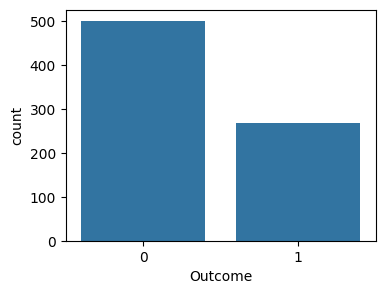

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,3))
sns.countplot(x='Outcome', data=df)
plt.show()

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print("Number of rows with 0 values for each variale")
for col in df.columns:
  missing_rows = df.loc[df[col] == 0].shape[0]
  print(col+": ", missing_rows)

Number of rows with 0 values for each variale
Pregnancies:  111
Glucose:  5
BloodPressure:  35
SkinThickness:  227
Insulin:  374
BMI:  11
DiabetesPedigreeFunction:  0
Age:  0
Outcome:  500


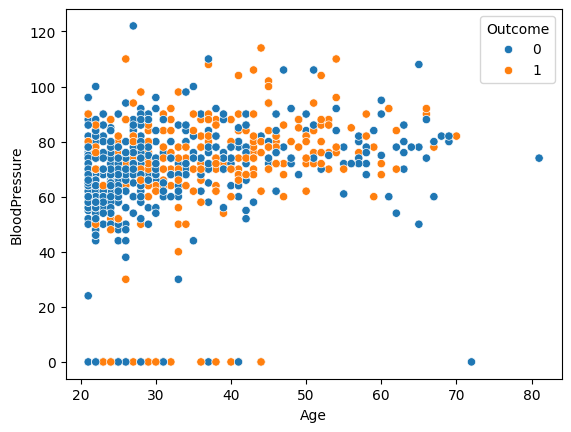

In [ ]:
sns.scatterplot(x='Age', y='BloodPressure', hue='Outcome', data=df)
plt.show()

In [12]:
cols = [c for c in df.columns if c != 'Outcome']

q1 = df[cols].quantile(0.25)
q3 = df[cols].quantile(0.75)

iqr = q3 - q1
iqr_15 = iqr * 1.5

lower = q1 - iqr_15
upper = q3 +iqr_15

In [15]:
iqr_data = pd.DataFrame({"속성": cols, "1사분위수": q1.values, "3사분위수": q3.values, "IQR*1.5": iqr_15.values, "최소값": lower.values, "최대값": upper.values})
display(iqr_data)

,속성,1사분위수,3사분위수,IQR*1.5,최소값,최대값
0,Pregnancies,1.00000,6.00000,7.50000,-6.500,13.500
1,Glucose,99.00000,140.25000,61.87500,37.125,202.125
2,BloodPressure,62.00000,80.00000,27.00000,35.000,107.000
3,SkinThickness,0.00000,32.00000,48.00000,-48.000,80.000
4,Insulin,0.00000,127.25000,190.87500,-190.875,318.125
5,BMI,27.30000,36.60000,13.95000,13.350,50.550
6,DiabetesPedigreeFunction,0.24375,0.62625,0.57375,-0.330,1.200
7,Age,24.00000,41.00000,25.50000,-1.500,66.500


<Axes: >

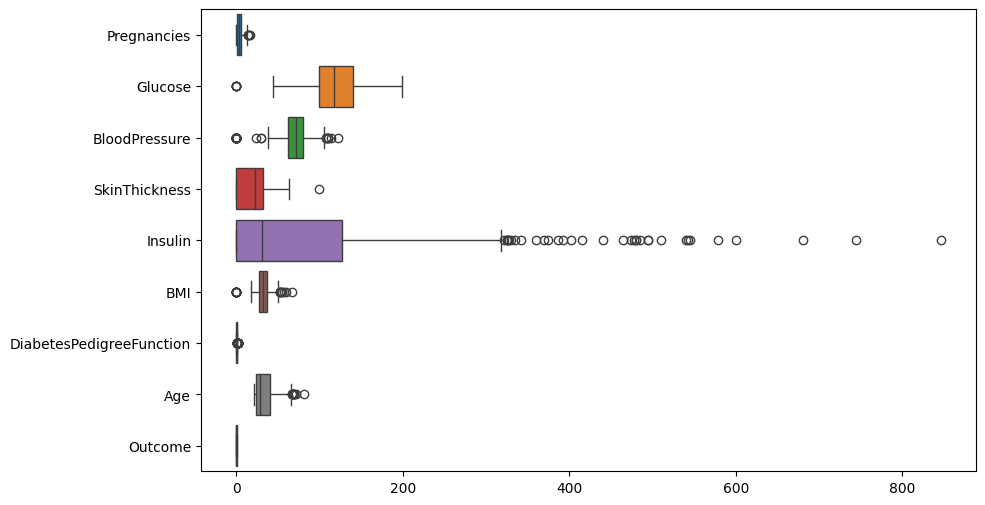

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, orient='h')

In [ ]:
condition = pd.Series(True, index=df.index)

for _, row in iqr_data.iterrows():
  col = row['속성']
  condition &= (df[col] >= row['최소값']) & (df[col] <= row['최대값'])

df2 = df[condition]
df2 = df2[(df2.SkinThickness>=1) & (df2.Insulin>=1)]
display(df2)

In [19]:
X = df2.drop('Outcome', axis=1)
y = df2['Outcome']

In [20]:
print("특징 모양: ", X.shape)
print("타깃 모양: ", y.shape)

특징 모양:  (332, 8)
타깃 모양:  (332,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

In [ ]:
#정규화: 평균과 범위는 훈련 데이터에서만 계산하고, 테스트 데이터에도 같은 값을 적용
#(분할 전에 전체 데이터로 계산하면 테스트 데이터 정보가 학습에 새어 들어감 = 데이터 누수)
X_mean = X_train.mean()
X_range = X_train.max() - X_train.min()
X_train_scaled = (X_train - X_mean) / X_range
X_test_scaled = (X_test - X_mean) / X_range
X_train_scaled.head()

In [23]:
#📊 로지스틱 회귀(Logistic Regression) 알고리즘
#정의: 독립 변수(입력 데이터)와 종속 변수(결과)를 연결해, 특정 사건이 발생할 확률을 예측하는 통계적 모델.
#결과값을 0~1 사이 확률로 표현.
#이진 분류(Binary Classification) 문제에 자주 사용 (예: 스팸메일 여부, 질병 유무).
#선형 방정식을 시그모이드 함수(로지스틱 함수)에 적용하여 확률을 출력.

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

In [ ]:
import numpy as np
w=model.coef_
b=model.intercept_
print("w= ", np.round(w, 2))
print("b= ", np.round(b, 2))

In [ ]:
print("훈련 세트 점수: ", model.score(X_train_scaled, y_train))
print("테스트 세트 점수: ", model.score(X_test_scaled, y_test))

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
print(y_pred[5:10])
print(y_test[5:10])

In [ ]:
from sklearn.metrics import confusion_matrix

conf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf, annot=True, cmap='Blues', fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Diabetes Classification')
plt.show()

## SMOTE로 클래스 불균형 보정

SMOTE는 소수 클래스(당뇨병=1)의 가짜 샘플을 만들어 클래스 비율을 맞춥니다.

- 가짜 샘플이 테스트 세트에 섞이지 않도록 **훈련 데이터에만** 적용합니다.
- 테스트 세트는 위에서 나눈 원본을 그대로 써서, 기본 모델과 같은 기준으로 비교합니다.
- SMOTE의 목적은 정확도가 아니라 소수 클래스 **재현율**을 높이는 것입니다. 정확도는 오히려 낮아질 수 있으므로 두 지표를 함께 봅니다.

In [ ]:
from imblearn.over_sampling import SMOTE

#min-max 정규화: 최솟값·최댓값은 훈련 데이터 기준
X_min = X_train.min()
X_max = X_train.max()
X2_train_scaled = (X_train - X_min) / (X_max - X_min)
X2_test_scaled = (X_test - X_min) / (X_max - X_min)

#SMOTE는 훈련 데이터에만 적용
oversample = SMOTE(random_state=42)
X2_train_res, y2_train_res = oversample.fit_resample(X2_train_scaled, y_train)
print("SMOTE 전 훈련 데이터:", y_train.value_counts().to_dict())
print("SMOTE 후 훈련 데이터:", y2_train_res.value_counts().to_dict())

In [ ]:
model2 = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model2.fit(X2_train_res, y2_train_res)
y_pred2 = model2.predict(X2_test_scaled)

In [ ]:
#같은 테스트 세트에서 두 모델 비교
from sklearn.metrics import accuracy_score, recall_score
print("기본 모델  - 정확도: %.3f, 재현율(당뇨병): %.3f" % (accuracy_score(y_test, y_pred), recall_score(y_test, y_pred)))
print("SMOTE 모델 - 정확도: %.3f, 재현율(당뇨병): %.3f" % (accuracy_score(y_test, y_pred2), recall_score(y_test, y_pred2)))

In [ ]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(6,4))
conf = confusion_matrix(y_test, y_pred2)
sns.heatmap(conf,annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Diabetes Classification (SMOTE)')
plt.show()

In [ ]:
df_new = pd.read_csv(DATA_DIR / 'new' / 'new_diabetes.csv')
df_new.head()

In [ ]:
#새 데이터도 훈련 데이터의 최솟값·최댓값으로 정규화
df_new_scaled = (df_new - X_min) / (X_max - X_min)
df_new_scaled

In [ ]:
print(model2.predict(df_new_scaled))